  MEAN REVERSION BACKTEST



[                       0%                       ]

Fetched 503 tickers



[*********************100%***********************]  503 of 503 completed



Building price matrix...
Running backtest...

  BACKTEST RESULTS
  Starting capital:   $100,000
  Final value:        $131,531
  Strategy return:    +31.5%
  SPY return:         +31.1%
  Outperformance:     +0.4%
  Max drawdown:       -6.6%
  Sharpe ratio:       1.91

Generating chart...


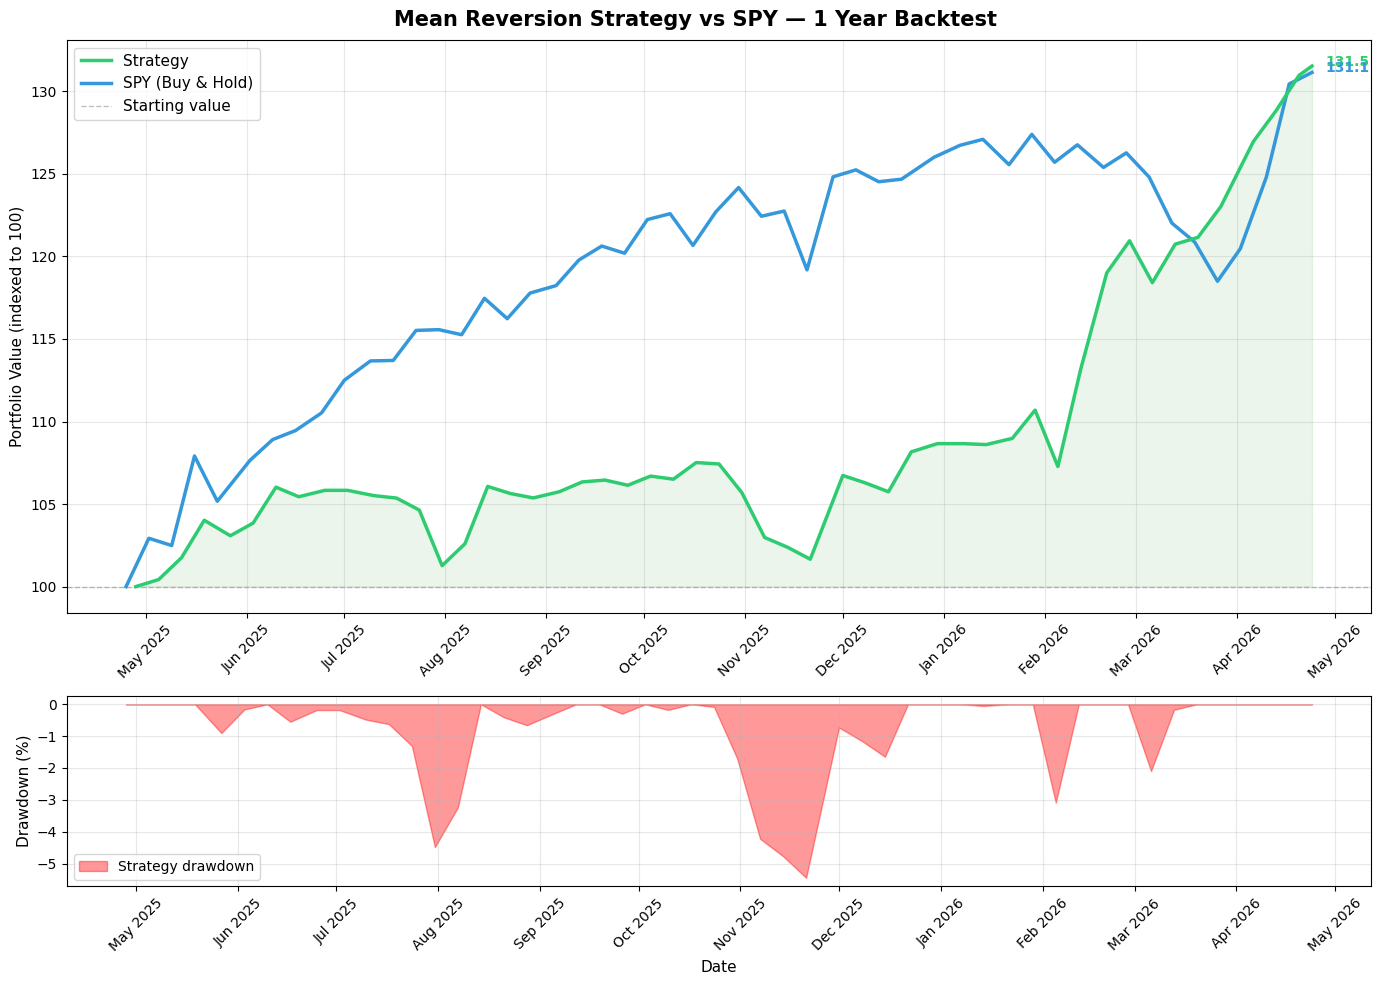

In [16]:
"""
This backtest was generated with the help of Claude AI from Anthropic. I opted for this 
rather than building it from scratch as I added it late in the project and my main focus  
was on the research and statistical analysis rather than backtest engineering. Its main 
purpose is to provide an easy way to check how the strategy would have fared over the last
year at different portfolio weights and to compare against the S&P 500. The methodology, 
parameters, and interpretation of results, though, are entirely my own.

A lot of the generated code is based off the notebook I had written for my initial
research.
"""

# =============================================================================
# S&P 500 Post-Shock Mean Reversion — Backtest
# Simulates the strategy over the last year and plots portfolio vs SPY
# =============================================================================

import warnings
warnings.filterwarnings('ignore')

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
from io import StringIO
import requests

# =============================================================================
# CONFIGURATION
# =============================================================================

STARTING_CAPITAL    = 100_000      # starting portfolio value ($)
POSITION_SIZE_PCT   = 0.06         # 3% of portfolio per trade (half Kelly)
THRESHOLD           = 0.10         # 10% single-day drop to trigger entry
HOLD_DAYS           = 5            # trading days to hold each position
TRANSACTION_COST    = 0.0        # 0.4% round-trip friction per trade

# =============================================================================
# TICKERS
# =============================================================================

def get_sp500_tickers():
    try:
        headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36'}
        url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
        response = requests.get(url, headers=headers)
        tables = pd.read_html(StringIO(response.text))
        tickers = tables[0]['Symbol'].tolist()
        return [t.replace('.', '-') for t in tickers]
    except:
        print("WARNING: Could not fetch S&P 500 list. Using fallback subset.")
        return [
            'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'NVDA', 'META', 'TSLA', 'BRK-B', 'LLY', 'AVGO',
            'JPM', 'V', 'UNH', 'XOM', 'WMT', 'MA', 'JNJ', 'PG', 'COST', 'HD',
            'NFLX', 'BAC', 'ABBV', 'CRM', 'KO', 'ORCL', 'MRK', 'CVX', 'AMD', 'PEP',
            'ACN', 'ADBE', 'TMO', 'LIN', 'MCD', 'CSCO', 'DIS', 'ABT', 'WFC', 'INTC',
            'QCOM', 'VZ', 'DHR', 'TXN', 'CMCSA', 'PM', 'INTU', 'AMGN', 'IBM', 'COP',
            'NEE', 'HON', 'UNP', 'RTX', 'LOW', 'CAT', 'SPGI', 'AMAT', 'PFE', 'BA',
            'GE', 'UBER', 'BLK', 'DE', 'T', 'ELV', 'SYK', 'AXP', 'MS', 'MDT',
            'BKNG', 'GILD', 'TJX', 'PLD', 'VRTX', 'ADI', 'CI', 'SCHW', 'REGN', 'MMC',
            'C', 'LRCX', 'CB', 'SBUX', 'FI', 'ISRG', 'SO', 'MO', 'BMY', 'NOC',
            'AMT', 'PYPL', 'ETN', 'BSX', 'DUK', 'WM', 'ZTS', 'PGR', 'ITW', 'EOG',
            'APH', 'CME', 'BDX', 'AON', 'CL', 'CSX', 'MCO', 'GD', 'EMR', 'EQIX',
            'MMM', 'ICE', 'SLB', 'PH', 'HCA', 'NSC', 'USB', 'PSA', 'MDLZ', 'APD',
            'TGT', 'SHW', 'MAR', 'KLAC', 'GM', 'ECL', 'SNPS', 'MSI', 'WELL', 'ADM',
            'MCK', 'ADP', 'MPC', 'F', 'ROP', 'CDNS', 'TT', 'CCI', 'NXPI', 'ORLY',
            'COIN', 'AJG', 'TDG', 'PCAR', 'PSX', 'AFL', 'OKE', 'JCI', 'FDX', 'CMG',
            'AIG', 'SRE', 'FTNT', 'AZO', 'TRV', 'TEL', 'MNST', 'HUM', 'D', 'KMB',
            'ROST', 'AEP', 'PAYX', 'ALL', 'GIS', 'MSCI', 'SPG', 'HLT', 'CARR', 'O',
            'KMI', 'NEM', 'ANET', 'PRU', 'CTVA', 'FAST', 'DLR', 'BK', 'YUM', 'EA',
            'PCG', 'SYY', 'ODFL', 'CMI', 'IDXX', 'RSG', 'KHC', 'VRSK', 'CPRT', 'KR',
            'DD', 'CTAS', 'IT', 'GWW', 'OTIS', 'XEL', 'MCHP', 'EW', 'AME', 'BKR',
            'KEYS', 'HES', 'VMC', 'A', 'EXC', 'IQV', 'ROK', 'ACGL', 'RMD', 'VICI',
            'HSY', 'DOW', 'PPG', 'TROW', 'MTD', 'GEHC', 'ANSS', 'DVN', 'GLW', 'IR',
            'WMB', 'MLM', 'HAL', 'WTW', 'EXR', 'PWR', 'FANG', 'EFX', 'LHX', 'LVS',
            'DXCM', 'ED', 'CEG', 'CHTR', 'DAL', 'STZ', 'HPQ', 'CTSH', 'DHI', 'CAH',
            'URI', 'LEN', 'CBRE', 'VLO', 'FTV', 'WAB', 'DFS', 'CDW', 'WEC', 'TSCO',
            'ETR', 'SBAC', 'TTWO', 'BIIB', 'HPE', 'STT', 'LYB', 'MPWR', 'AEE', 'TRGP'
        ]

# =============================================================================
# DATA DOWNLOAD
# =============================================================================

def download_all_data(tickers, start_date, end_date):
    print(f"Downloading data for {len(tickers)} stocks...")
    data = yf.download(tickers, start=start_date, end=end_date, progress=True, group_by='ticker')
    spy  = yf.download('SPY', start=start_date, end=end_date, progress=False)
    spy.index = pd.to_datetime(spy.index)
    spy.columns = spy.columns.droplevel(1) if isinstance(spy.columns, pd.MultiIndex) else spy.columns  # <-- add this
    return data, spy

# =============================================================================
# BACKTEST ENGINE
# =============================================================================

def run_backtest(tickers, data, spy, starting_capital):

    # Build a clean price matrix — one column per ticker
    print("\nBuilding price matrix...")
    prices = {}
    for ticker in tickers:
        try:
            col = data[ticker]['Close'] if isinstance(data.columns, pd.MultiIndex) else data['Close']
            if len(col.dropna()) >= 10:
                prices[ticker] = col
        except:
            continue
    prices = pd.DataFrame(prices).sort_index()
    prices.index = pd.to_datetime(prices.index)

    trading_days = prices.index
    spy_close    = spy['Close'].reindex(trading_days).ffill()

    # Portfolio state
    portfolio_value = starting_capital
    cash            = starting_capital
    open_trades     = []   # list of dicts: {ticker, entry_date, exit_date, shares, entry_price, position_value}

    # Track portfolio value daily
    daily_values = {}

    print("Running backtest...")

    for day_idx in range(1, len(trading_days)):
        today     = trading_days[day_idx]
        yesterday = trading_days[day_idx - 1]

        # --- 1. Close any trades whose hold period is up ---
        still_open = []
        for trade in open_trades:
            if today >= trade['exit_date']:
                exit_price = prices.loc[today, trade['ticker']]
                if pd.isna(exit_price):
                    still_open.append(trade)
                    continue
                raw_return   = (exit_price - trade['entry_price']) / trade['entry_price']
                net_return   = raw_return - TRANSACTION_COST
                trade_pnl    = trade['position_value'] * net_return
                cash        += trade['position_value'] + trade_pnl
            else:
                still_open.append(trade)
        open_trades = still_open

        # --- 2. Recalculate portfolio value (cash + mark-to-market open trades) ---
        mtm = 0
        for trade in open_trades:
            current_price = prices.loc[today, trade['ticker']]
            if not pd.isna(current_price):
                mtm += trade['position_value'] * (current_price / trade['entry_price'])
            else:
                mtm += trade['position_value']
        portfolio_value = cash + mtm

        # --- 3. Scan for new entry signals ---
        for ticker in prices.columns:
            price_today     = prices.loc[today, ticker]
            price_yesterday = prices.loc[yesterday, ticker]

            if pd.isna(price_today) or pd.isna(price_yesterday) or price_yesterday == 0:
                continue

            daily_return = (price_today - price_yesterday) / price_yesterday

            if daily_return <= -THRESHOLD:
                # Check how many trading days forward we can go for exit
                future_idx = day_idx + HOLD_DAYS
                if future_idx >= len(trading_days):
                    continue
                exit_date = trading_days[future_idx]

                position_value = portfolio_value * POSITION_SIZE_PCT

                # Don't open if we don't have the cash
                if position_value > cash:
                    continue

                cash -= position_value
                open_trades.append({
                    'ticker':         ticker,
                    'entry_date':     today,
                    'exit_date':      exit_date,
                    'entry_price':    price_today,
                    'position_value': position_value,
                })

        daily_values[today] = portfolio_value

    # Close any remaining open trades at last price
    last_day = trading_days[-1]
    for trade in open_trades:
        exit_price = prices.loc[last_day, trade['ticker']]
        if not pd.isna(exit_price):
            raw_return = (exit_price - trade['entry_price']) / trade['entry_price']
            net_return = raw_return - TRANSACTION_COST
            cash      += trade['position_value'] + trade['position_value'] * net_return
        else:
            cash += trade['position_value']
    daily_values[last_day] = cash

    portfolio_series = pd.Series(daily_values).sort_index()
    return portfolio_series

# =============================================================================
# WEEKLY RESAMPLING
# =============================================================================

def to_weekly(series):
    weekly = series.iloc[::5].copy()
    # Make sure the last actual day is always included
    if weekly.index[-1] != series.index[-1]:
        weekly[series.index[-1]] = series.iloc[-1]
    return weekly.sort_index()

# =============================================================================
# SUMMARY STATS
# =============================================================================

def print_summary(portfolio_series, spy_series, starting_capital):
    final_value    = portfolio_series.iloc[-1]
    total_return   = (final_value - starting_capital) / starting_capital * 100
    spy_start      = float(spy_series.iloc[0])
    spy_end        = float(spy_series.iloc[-1])
    spy_return     = (spy_end - spy_start) / spy_start * 100

    # Max drawdown
    rolling_max    = portfolio_series.cummax()
    drawdown       = (portfolio_series - rolling_max) / rolling_max * 100
    max_drawdown   = drawdown.min()

    # Sharpe ratio (annualised, risk-free rate ~4.3% currently)
    daily_returns  = portfolio_series.pct_change().dropna()
    risk_free_daily = 0.043 / 252
    excess_returns  = daily_returns - risk_free_daily
    sharpe          = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)

    print("\n" + "=" * 55)
    print("  BACKTEST RESULTS")
    print("=" * 55)
    print(f"  Starting capital:   ${starting_capital:,.0f}")
    print(f"  Final value:        ${final_value:,.0f}")
    print(f"  Strategy return:    {total_return:+.1f}%")
    print(f"  SPY return:         {spy_return:+.1f}%")
    print(f"  Outperformance:     {total_return - spy_return:+.1f}%")
    print(f"  Max drawdown:       {max_drawdown:.1f}%")
    print(f"  Sharpe ratio:       {float(sharpe):.2f}")
    print("=" * 55)

# =============================================================================
# VISUALISATION
# =============================================================================

def plot_results(portfolio_weekly, spy_weekly, starting_capital):
    # Normalise both to 100 at start
    port_norm = portfolio_weekly / portfolio_weekly.iloc[0] * 100
    spy_norm  = spy_weekly       / spy_weekly.iloc[0]       * 100

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={'height_ratios': [3, 1]})
    fig.suptitle('Mean Reversion Strategy vs SPY — 1 Year Backtest', fontsize=15, fontweight='bold')

    # --- Top: Portfolio growth ---
    ax1.plot(port_norm.index, port_norm.values, color='#2ecc71', linewidth=2.5, label='Strategy', zorder=3)
    ax1.plot(spy_norm.index,  spy_norm.values,  color='#3498db', linewidth=2.5, label='SPY (Buy & Hold)', zorder=2)
    ax1.axhline(100, color='grey', linestyle='--', linewidth=1, alpha=0.5, label='Starting value')
    ax1.fill_between(port_norm.index, port_norm.values, 100,
                     where=(port_norm.values >= 100), alpha=0.08, color='green')
    ax1.fill_between(port_norm.index, port_norm.values, 100,
                     where=(port_norm.values < 100),  alpha=0.08, color='red')
    ax1.set_ylabel('Portfolio Value (indexed to 100)', fontsize=11)
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax1.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

    # Annotate final values
    ax1.annotate(f"{port_norm.iloc[-1]:.1f}",
                 xy=(port_norm.index[-1], port_norm.iloc[-1]),
                 xytext=(10, 0), textcoords='offset points',
                 color='#2ecc71', fontweight='bold', fontsize=10)
    ax1.annotate(f"{spy_norm.iloc[-1]:.1f}",
                 xy=(spy_norm.index[-1], spy_norm.iloc[-1]),
                 xytext=(10, 0), textcoords='offset points',
                 color='#3498db', fontweight='bold', fontsize=10)

    # --- Bottom: Drawdown ---
    rolling_max = portfolio_weekly.cummax()
    drawdown    = (portfolio_weekly - rolling_max) / rolling_max * 100
    ax2.fill_between(drawdown.index, drawdown.values, 0, color='red', alpha=0.4, label='Strategy drawdown')
    ax2.set_ylabel('Drawdown (%)', fontsize=11)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

    plt.tight_layout()
    plt.show()

# =============================================================================
# MAIN
# =============================================================================

if __name__ == "__main__":
    end_date   = datetime.now()
    start_date = end_date - timedelta(days=365)

    print("=" * 55)
    print("  MEAN REVERSION BACKTEST")
    print("=" * 55 + "\n")

    tickers          = get_sp500_tickers()
    print(f"Fetched {len(tickers)} tickers\n")

    data, spy        = download_all_data(tickers, start_date, end_date)
    portfolio_series = run_backtest(tickers, data, spy, STARTING_CAPITAL)

    portfolio_weekly = to_weekly(portfolio_series)
    spy_weekly       = to_weekly(spy['Close'])

    print_summary(portfolio_series, spy['Close'], STARTING_CAPITAL)

    print("\nGenerating chart...")
    plot_results(portfolio_weekly, spy_weekly, STARTING_CAPITAL)